In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
file_path = 'StudentsPerformance.csv'  # Replace with the correct path
data = pd.read_csv(file_path)

In [3]:
X = data[['gender', 'race/ethnicity', 'parental level of education', 'lunch', 
          'test preparation course', 'reading score', 'writing score']]
y = data['math score']

In [4]:
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical variables
categorical_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
encoder = OneHotEncoder(drop='first', sparse_output=False)  # Updated parameter
X_encoded = encoder.fit_transform(X[categorical_features])

# Combine encoded categorical features with numerical ones
X_numerical = X[['reading score', 'writing score']].values
X_processed = pd.DataFrame(
    np.hstack([X_encoded, X_numerical]),
    columns=encoder.get_feature_names_out(categorical_features).tolist() + ['reading score', 'writing score']
)


In [5]:
X_encoded = encoder.fit_transform(X[categorical_features])

In [6]:
X_numerical = X[['reading score', 'writing score']].values
X_processed = pd.DataFrame(
    data=np.hstack([X_encoded, X_numerical]),
    columns=encoder.get_feature_names_out(categorical_features).tolist() + ['reading score', 'writing score']
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2 Score): {r2}")


Mean Squared Error (MSE): 29.09516986671547
R-squared (R2 Score): 0.8804332983749565


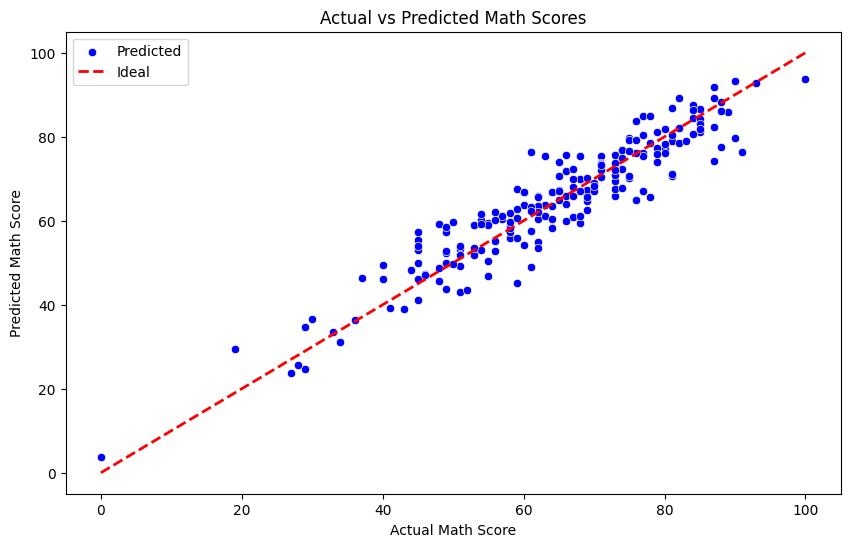

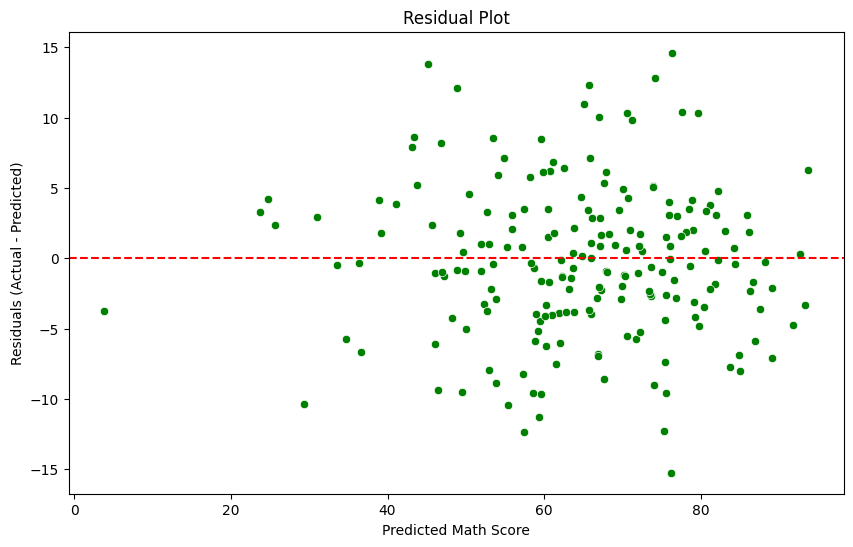

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Actual vs Predicted Math Scores')
plt.legend()
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Math Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()